# IMPORTS

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.svm import SVC, SVR
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score
from sklearn.ensemble import RandomForestClassifier

# GET DATA

In [2]:
left_features_df = pd.read_csv("dataset/processed/left_hand_features.csv")
# left_features_df = pd.DataFrame(left_features_df)
right_features_df = pd.read_csv("dataset/processed/right_hand_features.csv")
# right_features_df = pd.DataFrame(right_features_df)

In [3]:
left_features_df.head()

,num_taps,mean_peak_amp,std_peak_amp,amp_decrement,mean_iti,std_iti,cv_iti,num_long_pauses,prop_long_pauses,patient_id,hand,updrs,target
0,52,0.895847,0.043548,0.055189,0.542157,0.059807,0.110312,0,0.000000,C34,left,1,0
1,64,0.906656,0.050966,0.060950,0.452910,0.060022,0.132525,1,0.015873,C35,left,0,0
2,69,0.890518,0.125611,0.074415,0.420588,0.068068,0.161841,0,0.000000,C36,left,1,0
3,57,0.807915,0.192839,0.059099,0.522619,0.174785,0.334441,1,0.017857,C37,left,0,0
4,39,0.870205,0.111160,-0.050822,0.660088,0.189742,0.287450,1,0.026316,C38,left,0,0


In [4]:
right_features_df.head()

,num_taps,mean_peak_amp,std_peak_amp,amp_decrement,mean_iti,std_iti,cv_iti,num_long_pauses,prop_long_pauses,patient_id,hand,updrs,target
0,61,0.914892,0.047774,0.075582,0.467500,0.057205,0.122364,0,0.000000,C34,right,0,0
1,73,0.844620,0.148506,-0.074605,0.377778,0.105299,0.278734,4,0.055556,C35,right,0,0
2,60,0.951034,0.019800,0.014383,0.487006,0.054812,0.112550,0,0.000000,C36,right,0,0
3,26,0.934253,0.028889,0.023459,1.145333,0.244746,0.213689,1,0.040000,C37,right,0,0
4,36,0.925534,0.032226,-0.072683,0.778095,0.234648,0.301568,1,0.028571,C38,right,0,0


# MODEL TRAINING

In [45]:
# Prepare the data
X_left = left_features_df.drop(['patient_id', 'hand', 'updrs', 'target'], axis=1)
y_left = left_features_df['updrs']

# Split the data into training and testing sets
X_train_left, X_test_left, y_train_left, y_test_left = train_test_split(X_left, y_left, test_size=0.2, random_state=42)

# Scale the features
scaler_left = StandardScaler()
X_train_left = scaler_left.fit_transform(X_train_left)
X_test_left = scaler_left.transform(X_test_left)

import joblib
joblib.dump(scaler_left, "saved_models/left_scaler.pkl")


['saved_models/left_scaler.pkl']

In [46]:
# Prepare the data
X = right_features_df.drop(['patient_id', 'hand', 'updrs', 'target'], axis=1)
y = right_features_df['updrs']

# Split the data into training and testing sets
X_train_right, X_test_right, y_train_right, y_test_right = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler_right = StandardScaler()
X_train_right = scaler_right.fit_transform(X_train_right)
X_test_right = scaler_right.transform(X_test_right)

joblib.dump(scaler_right, "saved_models/right_scaler.pkl")

['saved_models/right_scaler.pkl']

In [29]:
# ─────────────────────────────────────────────────────────────
# TENSORS
# ─────────────────────────────────────────────────────────────
X_train_left  = torch.tensor(np.asarray(X_train_left),  dtype=torch.float32)
X_test_left   = torch.tensor(np.asarray(X_test_left),   dtype=torch.float32)
y_train_left  = torch.tensor(np.asarray(y_train_left),  dtype=torch.long)
y_test_left   = torch.tensor(np.asarray(y_test_left),   dtype=torch.long)

X_train_right = torch.tensor(np.asarray(X_train_right), dtype=torch.float32)
X_test_right  = torch.tensor(np.asarray(X_test_right),  dtype=torch.float32)
y_train_right = torch.tensor(np.asarray(y_train_right), dtype=torch.long)
y_test_right  = torch.tensor(np.asarray(y_test_right),  dtype=torch.long)

# ─────────────────────────────────────────────────────────────
# DATASETS & LOADERS
# ─────────────────────────────────────────────────────────────
class UPDRSDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader_left  = DataLoader(UPDRSDataset(X_train_left,  y_train_left),  batch_size=32, shuffle=True)
test_loader_left   = DataLoader(UPDRSDataset(X_test_left,   y_test_left),   batch_size=32, shuffle=False)
train_loader_right = DataLoader(UPDRSDataset(X_train_right, y_train_right), batch_size=32, shuffle=True)
test_loader_right  = DataLoader(UPDRSDataset(X_test_right,  y_test_right),  batch_size=32, shuffle=False)

In [34]:
# ─────────────────────────────────────────────────────────────
# MODEL ARCHITECTURE
# ─────────────────────────────────────────────────────────────
class UPDRSModel(nn.Module):
    def __init__(self, input_dim, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# ─────────────────────────────────────────────────────────────
# SHARED CONFIG — change once, applies to both sides
# ─────────────────────────────────────────────────────────────
N_EPOCHS   = 1000
LR         = 3e-4
WEIGHT_DECAY = 1e-4
NUM_CLASSES  = 3

criterion = nn.CrossEntropyLoss()  # same loss for both sides

# Initialise both models
left_model  = UPDRSModel(X_train_left.shape[1],  num_classes=NUM_CLASSES)
right_model = UPDRSModel(X_train_right.shape[1], num_classes=NUM_CLASSES)

# Each model needs its own optimizer (separate parameter sets)
optimizer_left  = optim.AdamW(left_model.parameters(),  lr=LR, weight_decay=WEIGHT_DECAY)
optimizer_right = optim.AdamW(right_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

In [36]:
# ─────────────────────────────────────────────────────────────
# TRAINING FUNCTION — write once, call twice
# ─────────────────────────────────────────────────────────────
def train_model(model, optimizer, train_loader, side):
    for epoch in range(N_EPOCHS):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        if (epoch + 1) % 250 == 0:
            print(f"[{side}] Epoch [{epoch+1}/{N_EPOCHS}], Loss: {epoch_loss/len(train_loader):.4f}")

    print(f"\n✅ {side} side CNN trained successfully.")

# ─────────────────────────────────────────────────────────────
# TRAIN BOTH SIDES
# ─────────────────────────────────────────────────────────────
train_model(left_model,  optimizer_left,  train_loader_left,  side="Left")
train_model(right_model, optimizer_right, train_loader_right, side="Right")

[Left] Epoch [250/1000], Loss: 0.0093
[Left] Epoch [500/1000], Loss: 0.0051
[Left] Epoch [750/1000], Loss: 0.0030
[Left] Epoch [1000/1000], Loss: 0.0023

✅ Left side CNN trained successfully.
[Right] Epoch [250/1000], Loss: 0.1234
[Right] Epoch [500/1000], Loss: 0.0829
[Right] Epoch [750/1000], Loss: 0.0530
[Right] Epoch [1000/1000], Loss: 0.0320

✅ Right side CNN trained successfully.


### SVC, SVR, RF Classifier 

In [39]:
#### LEFT HAND

#SVC
svc_left = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
y_train_left = y_train_left.ravel()
y_test_left = y_test_left.ravel()
svc_left.fit(X_train_left, y_train_left)

#SVR
svr_left = SVR(kernel='rbf', C=1.0, gamma='scale')
svr_left.fit(X_train_left, y_train_left)

#RFC
rf_left = RandomForestClassifier(n_estimators=50, random_state=42)
rf_left.fit(X_train_left, y_train_left)



#### RIGHT HAND

#SVC
svc_right = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
y_train_right = y_train_right.ravel()
y_test_right = y_test_right.ravel()
svc_right.fit(X_train_right, y_train_right)

#SVR
svr_right = SVR(kernel='rbf', C=1.0, gamma='scale')
svr_right.fit(X_train_right, y_train_right)

# RFC
rf_right = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_right.fit(X_train_right, y_train_right)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### Evaluation


  Random Forest — Left Side
  Accuracy:     0.6429
  Weighted F1:  0.6447

Classification Report:
                precision    recall  f1-score   support

    Mild (0-1)       0.71      0.62      0.67         8
Moderate (2-3)       0.57      0.67      0.62         6
    Severe (4)       0.00      0.00      0.00         0

      accuracy                           0.64        14
     macro avg       0.43      0.43      0.43        14
  weighted avg       0.65      0.64      0.64        14


  SVC — Left Side
  Accuracy:     0.7143
  Weighted F1:  0.7143

Classification Report:
                precision    recall  f1-score   support

    Mild (0-1)       0.75      0.75      0.75         8
Moderate (2-3)       0.67      0.67      0.67         6
    Severe (4)       0.00      0.00      0.00         0

      accuracy                           0.71        14
     macro avg       0.47      0.47      0.47        14
  weighted avg       0.71      0.71      0.71        14


  SVR — Left Side
  A

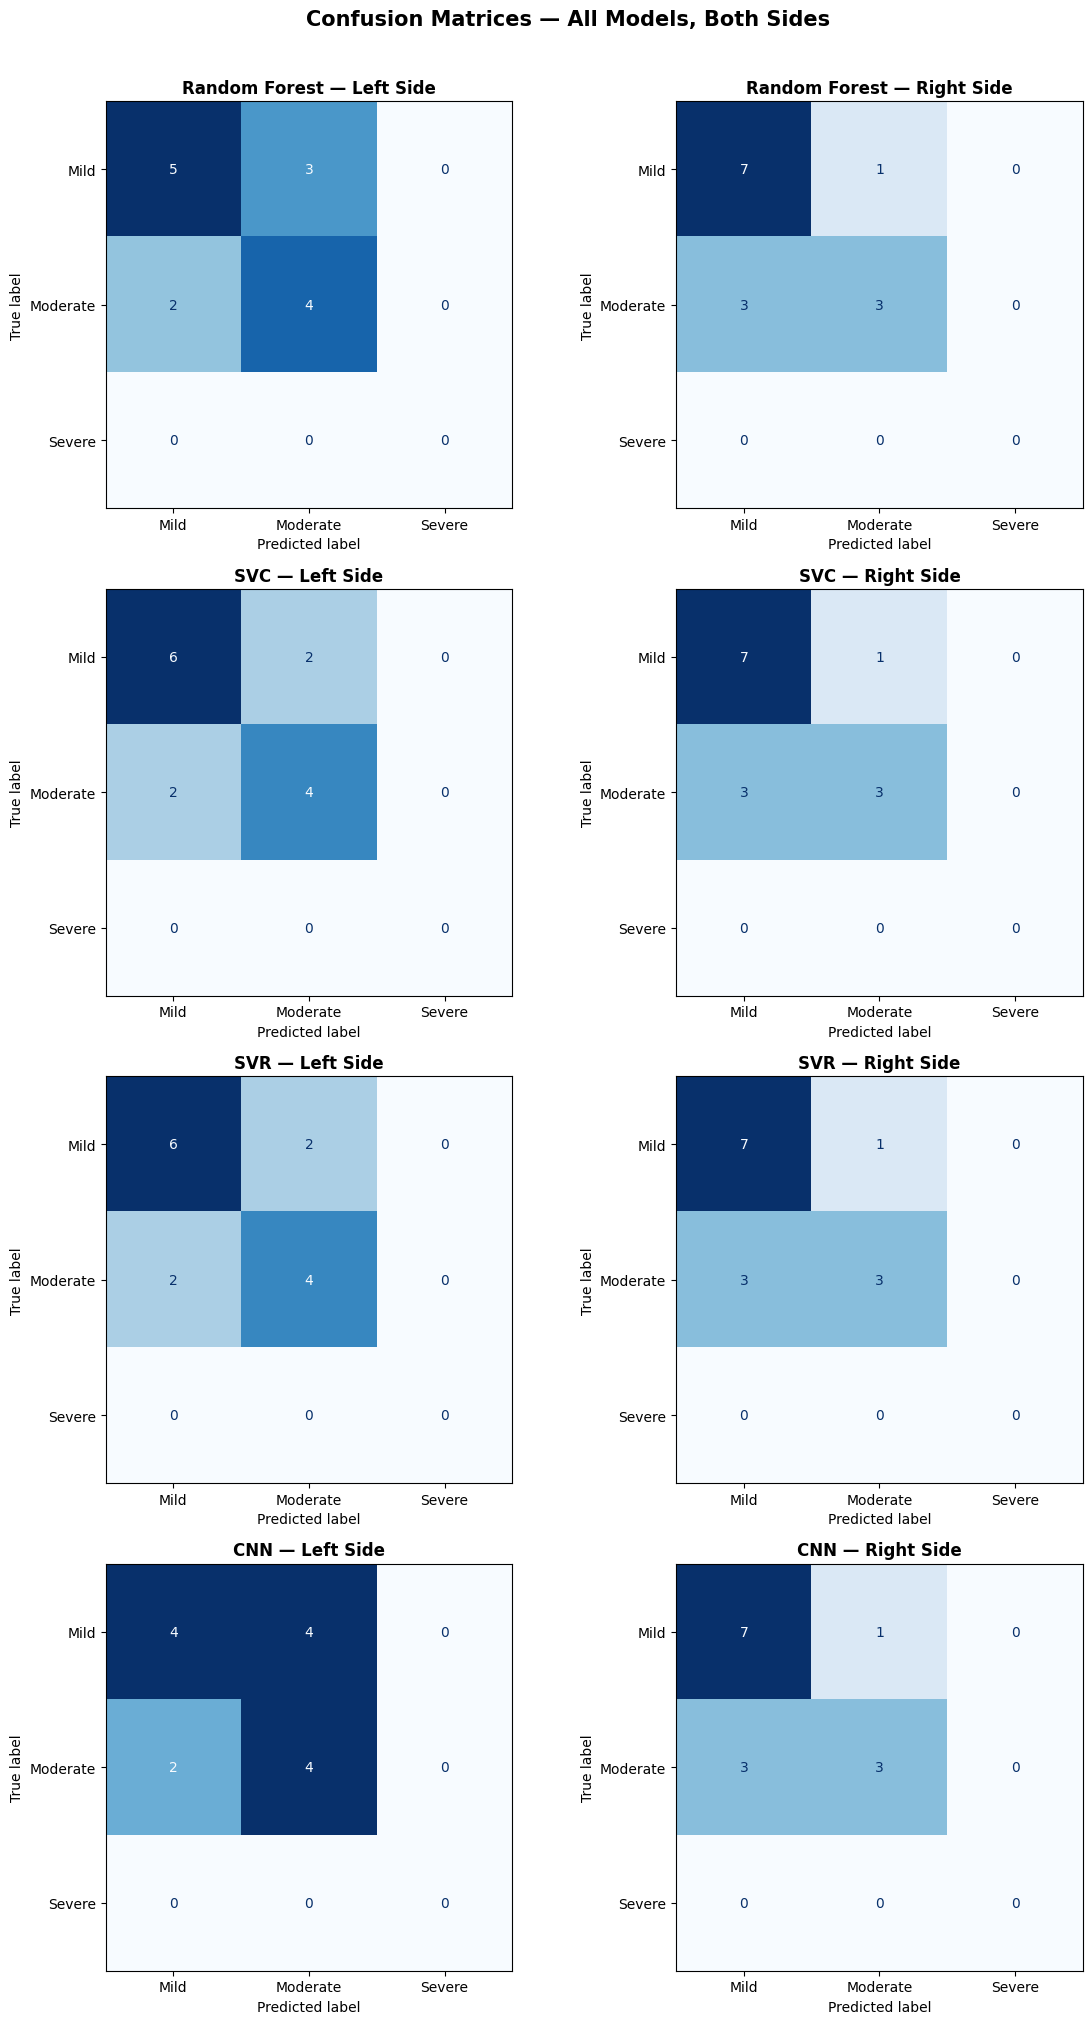

In [43]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# ─────────────────────────────────────────────────────────────
# GROUND TRUTH — extract once, used by all models both sides
# .numpy() converts tensors back to numpy for sklearn
# ─────────────────────────────────────────────────────────────
y_true_left  = y_test_left.numpy()
y_true_right = y_test_right.numpy()

# ─────────────────────────────────────────────────────────────
# HELPER FUNCTION
# ─────────────────────────────────────────────────────────────
def evaluate_model(model_name, side, y_true, y_pred):
    print(f"\n{'='*55}")
    print(f"  {model_name} — {side} Side")
    print(f"{'='*55}")
    print(f"  Accuracy:     {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Weighted F1:  {f1_score(y_true, y_pred, average='weighted', labels=[0,1,2], zero_division=0):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred,
                                labels=[0, 1, 2],
                                target_names=['Mild (0-1)', 'Moderate (2-3)', 'Severe (4)'],
                                zero_division=0))

# ─────────────────────────────────────────────────────────────
# GET PREDICTIONS — ALL MODELS, BOTH SIDES
# sklearn needs numpy so we call .numpy() on the tensors
# ─────────────────────────────────────────────────────────────

# ── Random Forest ──────────────────────────────────────────
rf_pred_left  = rf_left.predict(X_test_left.numpy())
rf_pred_right = rf_right.predict(X_test_right.numpy())

# ── SVC ────────────────────────────────────────────────────
svc_pred_left  = svc_left.predict(X_test_left.numpy())
svc_pred_right = svc_right.predict(X_test_right.numpy())

# ── SVR (round + clip to get class labels) ─────────────────
svr_pred_left  = np.clip(np.round(svr_left.predict(X_test_left.numpy())),   0, 2).astype(int)
svr_pred_right = np.clip(np.round(svr_right.predict(X_test_right.numpy())), 0, 2).astype(int)

# ── CNN ────────────────────────────────────────────────────
def get_cnn_predictions(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs = model(X_batch)
            preds.extend(torch.argmax(outputs, dim=1).numpy())
    return np.array(preds)

cnn_pred_left  = get_cnn_predictions(left_model,  test_loader_left)
cnn_pred_right = get_cnn_predictions(right_model, test_loader_right)

# ─────────────────────────────────────────────────────────────
# PRINT ALL METRICS — 4 models x 2 sides
# ─────────────────────────────────────────────────────────────
for side, y_true, rf_pred, svc_pred, svr_pred, cnn_pred in [
    ("Left",  y_true_left,  rf_pred_left,  svc_pred_left,  svr_pred_left,  cnn_pred_left),
    ("Right", y_true_right, rf_pred_right, svc_pred_right, svr_pred_right, cnn_pred_right),
]:
    evaluate_model("Random Forest", side, y_true, rf_pred)
    evaluate_model("SVC",           side, y_true, svc_pred)
    evaluate_model("SVR",           side, y_true, svr_pred)
    evaluate_model("CNN",           side, y_true, cnn_pred)

# ─────────────────────────────────────────────────────────────
# CONFUSION MATRICES — 4 models x 2 sides = 8 plots
# ─────────────────────────────────────────────────────────────
models_info = [
    ("Random Forest", rf_pred_left,  rf_pred_right),
    ("SVC",           svc_pred_left, svc_pred_right),
    ("SVR",           svr_pred_left, svr_pred_right),
    ("CNN",           cnn_pred_left, cnn_pred_right),
]

class_labels = ['Mild', 'Moderate', 'Severe']
fig, axes = plt.subplots(4, 2, figsize=(12, 20))
fig.suptitle("Confusion Matrices — All Models, Both Sides", fontsize=15, fontweight='bold', y=1.01)

for row, (model_name, pred_left, pred_right) in enumerate(models_info):
    for col, (side, y_true, y_pred) in enumerate([
        ("Left",  y_true_left,  pred_left),
        ("Right", y_true_right, pred_right),
    ]):
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
        disp.plot(ax=axes[row, col], cmap='Blues', colorbar=False)
        axes[row, col].set_title(f"{model_name} — {side} Side", fontweight='bold')

plt.tight_layout()
plt.savefig("all_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

### Save Models

In [44]:
import pickle
import torch
import os

# ─────────────────────────────────────────────────────────────
# CREATE OUTPUT DIRECTORY (optional but keeps things tidy)
# ─────────────────────────────────────────────────────────────
os.makedirs("saved_models", exist_ok=True)

# ─────────────────────────────────────────────────────────────
# SAVE SKLEARN MODELS — Random Forest, SVC, SVR (.pkl)
# pickle serialises the entire fitted model object so you can
# reload it later without retraining
# ─────────────────────────────────────────────────────────────
sklearn_models = {
    "saved_models/rf_left.pkl":   rf_left,
    "saved_models/rf_right.pkl":  rf_right,
    "saved_models/svc_left.pkl":  svc_left,
    "saved_models/svc_right.pkl": svc_right,
    "saved_models/svr_left.pkl":  svr_left,
    "saved_models/svr_right.pkl": svr_right,
}

for path, model in sklearn_models.items():
    with open(path, "wb") as f:
        pickle.dump(model, f)
    print(f"Saved: {path}")

# ─────────────────────────────────────────────────────────────
# SAVE CNN MODELS — .pth (PyTorch standard format)
# state_dict() saves only the learned weights, not the full
# model class — lighter and more portable than saving the
# entire object. You'll need to reinstantiate UPDRSModel()
# before loading.
# ─────────────────────────────────────────────────────────────
torch.save(left_model.state_dict(),  "saved_models/cnn_left.pth")
print("Saved: saved_models/cnn_left.pth")

torch.save(right_model.state_dict(), "saved_models/cnn_right.pth")
print("Saved: saved_models/cnn_right.pth")

print("\n✅ All models saved successfully.")

Saved: saved_models/rf_left.pkl
Saved: saved_models/rf_right.pkl
Saved: saved_models/svc_left.pkl
Saved: saved_models/svc_right.pkl
Saved: saved_models/svr_left.pkl
Saved: saved_models/svr_right.pkl
Saved: saved_models/cnn_left.pth
Saved: saved_models/cnn_right.pth

✅ All models saved successfully.
